In [1]:
import pandas as pd
df = pd.read_csv("../data/raw/osha_severe_injury_reports.csv")
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head()

Shape: (102922, 28)

Columns:
['ID', 'UPA', 'EventDate', 'Employer', 'Address1', 'Address2', 'City', 'State', 'Zip', 'Latitude', 'Longitude', 'Primary NAICS', 'Hospitalized', 'Amputation', 'Loss of Eye', 'Inspection', 'Final Narrative', 'Nature', 'NatureTitle', 'Part of Body', 'Part of Body Title', 'Event', 'EventTitle', 'Source', 'SourceTitle', 'Secondary Source', 'Secondary Source Title', 'FederalState']


C:\Users\vpj16\AppData\Local\Temp\ipykernel_39780\3485614537.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/osha_severe_injury_reports.csv")


,ID,UPA,EventDate,Employer,Address1,Address2,City,State,Zip,Latitude,...,NatureTitle,Part of Body,Part of Body Title,Event,EventTitle,Source,SourceTitle,Secondary Source,Secondary Source Title,FederalState
0,2015010015,931176,1/1/2015,FCI Otisville Federal Correctional Institution,Two Mile Drive,NaN,OTISVILLE,NEW YORK,10963.0,41.46,...,Fractures,513,Lower leg(s),1214,Injured by physical contact with person while ...,5721,Co-worker,5772.0,Inmate or detainee in custody,1
1,2015010016,930267,1/1/2015,Kalahari Manufacturing LLC,171 Progress Drive,NaN,LAKE DELTON,WISCONSIN,53940.0,43.59,...,Second degree heat (thermal) burns,519,"Leg(s), n.e.c.",317,"Ignition of vapors, gases, or liquids",7261,"Welding, cutting, and blow torches",NaN,NaN,1
2,2015010018,929823,1/1/2015,Schneider National Bulk Carrier,420 CORAOPOLIS ROAD,NaN,CORAOPOLIS,PENNSYLVANIA,15108.0,40.49,...,"Traumatic injuries and disorders, unspecified",9999,Nonclassifiable,4331,Other fall to lower level less than 6 feet,8421,"Semi, tractor-trailer, tanker truck",741.0,Ladders-fixed,1
3,2015010019,929711,1/1/2015,PEPSI BOTTLING GROUP INC.,4541 HOUSTON AVE.,NaN,MACON,GEORGIA,31206.0,32.77,...,"Soreness, pain, hurt-nonspecified injury",510,"Leg(s), unspecified",640,Caught in or compressed by equipment or object...,8623,Pallet jack-powered,8420.0,"Truck-motorized freight hauling and utility, u...",1
4,2015010020,929642,1/1/2015,North American Pipe Corporation,210 South Arch Street,NaN,JANESVILLE,WISCONSIN,53545.0,42.67,...,Fractures,4429,"Finger(s), fingernail(s), n.e.c.",6411,Caught in running equipment or machinery durin...,350,"Metal, woodworking, and special material machi...",NaN,NaN,1


In [2]:
print(f"Total records: {len(df)}")
print(f"\nInjury types:")
print(f"  Hospitalized: {df['Hospitalized'].sum()}")
print(f"  Amputation:   {df['Amputation'].sum()}")
print(f"  Loss of Eye:  {df['Loss of Eye'].sum()}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Total records: 102922

Injury types:
  Hospitalized: 84026.0
  Amputation:   27174.0
  Loss of Eye:  35.0

Missing values:
Address1                     18
Address2                  93835
City                         17
Zip                          24
Latitude                     67
Longitude                    67
Primary NAICS                 2
Amputation                    7
Loss of Eye                   5
Inspection                68211
Secondary Source          55381
Secondary Source Title    55381
dtype: int64


In [3]:
print("Top 15 Event Types:")
print(df['EventTitle'].value_counts().head(15))


Top 15 Event Types:
EventTitle
Caught in running equipment or machinery during regular operation             6687
Other fall to lower level, unspecified                                        5913
Caught in running equipment or machinery during maintenance, cleaning         5269
Compressed or pinched by shifting objects or equipment                        4977
Fall on same level due to slipping                                            3659
Other fall to lower level less than 6 feet                                    3308
Fall on same level due to tripping over an object                             2646
Struck against moving part of machinery or equipment                          2235
Exposure to environmental heat                                                2196
Caught in or compressed by equipment or objects, unspecified                  2143
Injured by slipping or swinging object held by injured worker                 2122
Struck by falling object or equipment, n.e.c.           

In [4]:
print("Top 15 Sources:")
print(df['SourceTitle'].value_counts().head(15))

Top 15 Sources:
SourceTitle
Floor, n.e.c.                                               5029
Forklift, order picker, platform truck-powered              3864
Nonclassifiable                                             2771
Floors, walkways, ground surfaces, unspecified              2429
Heat-environmental                                          2197
 Other constructed surface                                  1619
Machinery, unspecified                                      1619
Ladders, unspecified                                        1354
Movable ladders, unspecified                                1311
Step ladders                                                1173
Pallet jack-powered                                         1130
Semi, tractor-trailer, tanker truck                         1034
Truck-motorized freight hauling and utility, unspecified     896
Roofs, unspecified                                           893
Scaffolds-staging, unspecified                               7

In [5]:
# create a single severity column for our target
# 3 = loss of eye, 2 = amputation, 1 = hospitalization
df['severity'] = 0
df.loc[df['Hospitalized'] == 1, 'severity'] = 1
df.loc[df['Amputation'] == 1, 'severity'] = 2
df.loc[df['Loss of Eye'] == 1, 'severity'] = 3

print("Severity distribution:")
print(df['severity'].value_counts().sort_index())


Severity distribution:
severity
0      627
1    75121
2    27139
3       35
Name: count, dtype: int64


In [6]:
# binary target: 0 = hospitalized, 1 = severe (amputation/eye loss)
df['severe'] = ((df['Amputation'] == 1) | (df['Loss of Eye'] == 1)).astype(int)
print(f"Severe: {df['severe'].sum()} ({df['severe'].mean()*100:.1f}%)")
print(f"Not severe: {(df['severe'] == 0).sum()} ({(df['severe'] == 0).mean()*100:.1f}%)")


Severe: 27174 (26.4%)
Not severe: 75748 (73.6%)


In [7]:
from sklearn.preprocessing import LabelEncoder

# select features we'll use
feature_cols = ['EventTitle', 'SourceTitle', 'NatureTitle', 'Part of Body Title', 'Primary NAICS']

# drop rows with missing values in our feature columns
df_clean = df[feature_cols + ['severe']].dropna()
print(f"Records after dropping nulls: {len(df_clean)} (dropped {len(df) - len(df_clean)})")

# encode categorical features
encoders = {}
for col in feature_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    encoders[col] = le
    print(f"{col}: {len(le.classes_)} unique values")


Records after dropping nulls: 102920 (dropped 2)
EventTitle: 644 unique values
SourceTitle: 1933 unique values
NatureTitle: 345 unique values
Part of Body Title: 274 unique values
Primary NAICS: 1287 unique values


In [ ]:
# only use features available BEFORE an injury
safe_features = ['EventTitle', 'SourceTitle', 'Primary NAICS']

X = df_clean[safe_features]
y = df_clean['severe']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    eval_metric='logloss',
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"\n{classification_report(y_test, y_pred)}")


AUC-ROC: 0.9223

              precision    recall  f1-score   support

           0       0.95      0.85      0.90     15149
           1       0.67      0.88      0.76      5435

    accuracy                           0.86     20584
   macro avg       0.81      0.87      0.83     20584
weighted avg       0.88      0.86      0.86     20584



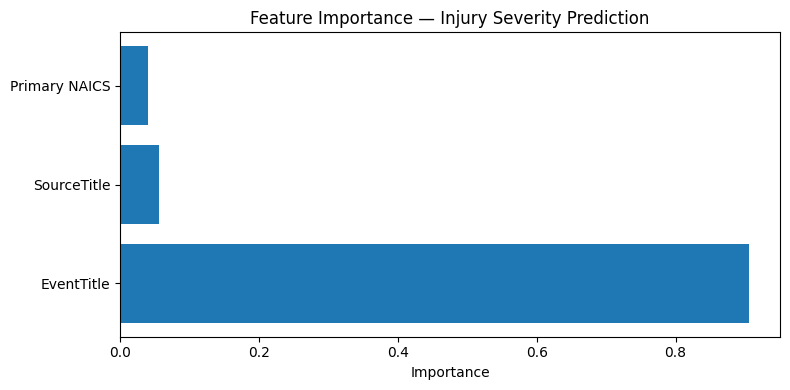

In [10]:
import matplotlib.pyplot as plt

importance = dict(zip(safe_features, model.feature_importances_))
plt.figure(figsize=(8, 4))
plt.barh(list(importance.keys()), list(importance.values()))
plt.title("Feature Importance — Injury Severity Prediction")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../models/feature_importance.png", dpi=150)
plt.show()


In [11]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

# save model
joblib.dump(model, "../models/injury_predictor.pkl")

# save encoders (needed to encode new inputs at inference time)
joblib.dump(encoders, "../models/label_encoders.pkl")

print("Saved model and encoders to models/")

Saved model and encoders to models/


In [12]:
# test: predict severity for "caught in machinery" at a construction site
loaded_model = joblib.load("../models/injury_predictor.pkl")
loaded_encoders = joblib.load("../models/label_encoders.pkl")

test_input = {
    'EventTitle': 'Caught in running equipment or machinery during regular operation',
    'SourceTitle': 'Machinery, unspecified',
    'Primary NAICS': 238220,  # plumbing/HVAC construction
}

encoded = {}
for col, val in test_input.items():
    le = loaded_encoders[col]
    if val in le.classes_:
        encoded[col] = le.transform([val])[0]
    else:
        encoded[col] = 0  # unknown category fallback

prob = loaded_model.predict_proba(pd.DataFrame([encoded]))[0][1]
print(f"Injury severity probability: {prob:.2%}")

Injury severity probability: 89.66%
